<a href="https://colab.research.google.com/github/xanuragx-0/wind-turbine-fault-detection/blob/main/Final_MVKDE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
%matplotlib inline
import seaborn as sns
from matplotlib.pylab import rcParams
import matplotlib.pyplot as plt
# Import the necessary libraries
import numpy as np
import pandas as pd
from sklearn.neighbors import KernelDensity
from sklearn.metrics import classification_report
from keras import metrics
import keras
import tensorflow as tf
import os
sns.set(style='whitegrid', palette='muted')
rcParams['figure.figsize'] = 14, 8

In [ ]:
import time
# record start time
start = time.time()

In [ ]:
data = pd.read_csv("CM_data.csv")

In [ ]:
data.describe()

,Gear_oil_inlet_pressure,Gear_oil_inlet_temp,Gear_oil_pump_pressure,Gear_oil_temp,Gearbox_speed,Generator_bearing_rear_temp,Generator_bearing_front_temp,Generator_RPM,Front_bearing_temperature,Rear_bearing_temperature,Rotor_bearing_temp,Rotor_speed,Wind_speed,Wind_direction,Power
count,26016.000000,23821.000000,26016.000000,23821.000000,23821.000000,26016.000000,26016.000000,26016.000000,23821.000000,23821.000000,26016.000000,26016.000000,26016.000000,26016.000000,26016.000000
mean,108.597837,44.982170,431.193948,50.690631,1166.548057,39.145521,37.717245,1154.913543,63.195857,61.247966,27.219303,9.727392,5.750563,178.961618,579.764966
std,65.898297,10.276888,222.261749,8.155401,545.483733,6.195743,6.174440,536.529916,13.456528,11.899170,4.930175,4.535585,2.877248,103.734005,654.381396
min,-1.869535,6.590000,0.110000,11.190000,0.000000,8.168750,11.500000,0.000000,10.600000,10.420000,6.600000,0.000000,0.229894,0.012631,-17.010895
25%,78.068895,38.797500,343.351187,48.955001,970.485375,36.872430,34.655198,969.523314,57.780000,59.431580,24.849342,8.149787,3.594361,73.980208,69.819445
50%,93.949340,46.762500,401.606853,52.572499,1194.154066,39.494558,38.950001,1175.535164,69.332500,66.155000,27.905000,9.891573,5.311006,199.630070,297.875524
75%,158.136913,53.840000,609.626841,56.080000,1659.207367,42.159999,42.060626,1620.286695,72.695000,68.470000,30.397099,13.663272,7.410848,262.718061,893.487160
max,311.565883,58.800000,989.700613,59.905000,1816.579691,73.860001,60.245000,1811.751337,77.245002,73.164999,38.395002,15.302300,22.173118,359.990140,2076.354102


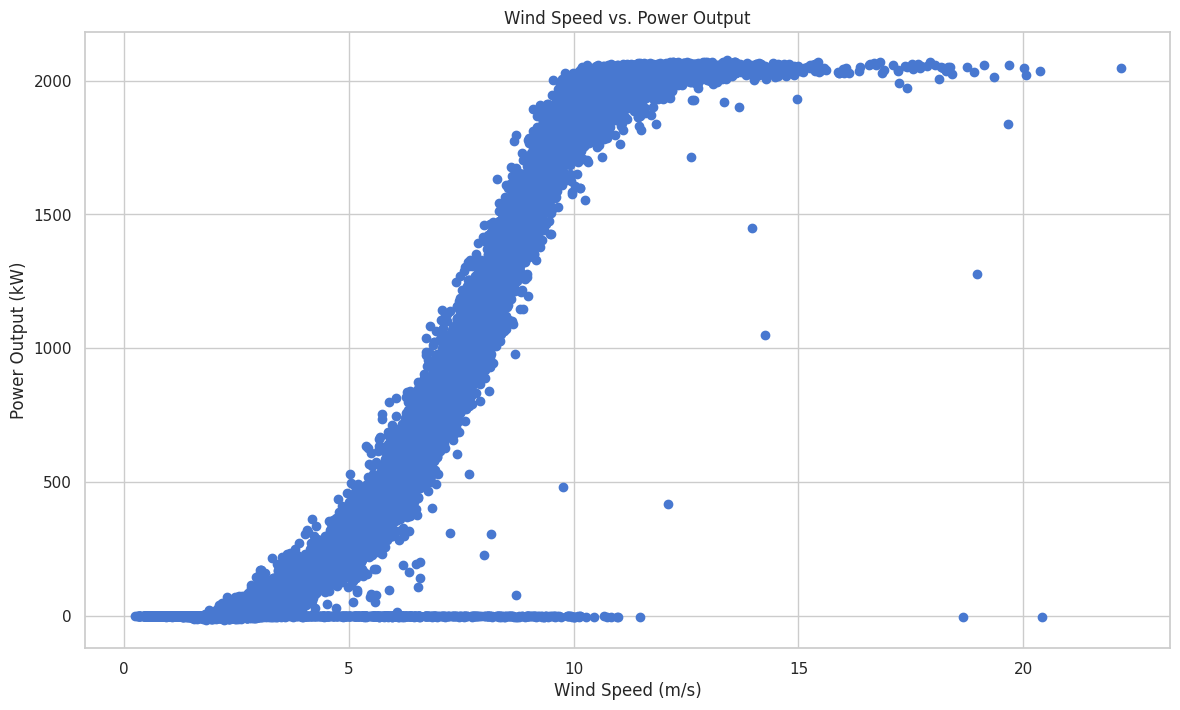

In [ ]:
# prompt: plot wind spped and power as a scatter plot

import matplotlib.pyplot as plt


# Create a scatter plot of wind speed and power
plt.scatter(data['Wind_speed'], data['Power'])

# Set the title and axis labels
plt.title('Wind Speed vs. Power Output')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Power Output (kW)')

# Display the plot
plt.show()


In [ ]:
# drop all rows that contain 'Coca Cola'
data = data.drop(data[data['Wind_speed'] <3 ].index)
data = data.drop(data[data['Wind_speed'] >22 ].index)
data = data.drop(data[data['Power'] <0 ].index)
data = data.dropna()
data.to_csv("clean_data.csv")

In [ ]:
data1 = pd.read_csv("clean_data.csv")
data1.describe()

,Unnamed: 0,Gear_oil_inlet_pressure,Gear_oil_inlet_temp,Gear_oil_pump_pressure,Gear_oil_temp,Gearbox_speed,Generator_bearing_rear_temp,Generator_bearing_front_temp,Generator_RPM,Front_bearing_temperature,Rear_bearing_temperature,Rotor_bearing_temp,Rotor_speed,Wind_speed,Wind_direction,Power
count,19025.000000,19025.000000,19025.000000,19025.000000,19025.000000,19025.000000,19025.000000,19025.000000,19025.000000,19025.000000,19025.000000,19025.000000,19025.000000,19025.000000,19025.000000,19025.000000
mean,11772.965782,133.738574,46.845682,517.335031,53.293063,1378.667269,40.006367,38.209885,1375.367948,68.601666,65.968092,28.161785,11.591899,6.651802,186.598521,755.320788
std,6838.272367,53.655593,8.989809,162.822656,4.351409,329.170102,4.809344,5.674453,327.980843,6.631573,4.609817,3.618003,2.779574,2.635631,96.190385,670.712208
min,101.000000,-1.180031,9.475000,50.136058,12.992500,8.962858,10.375000,12.320000,4.147972,25.260000,23.202500,6.712500,0.000000,3.000301,0.057135,0.000000
25%,5836.000000,87.520289,40.427501,372.933702,50.715000,1062.117755,37.257499,34.742501,1060.261082,65.725000,64.647500,25.744737,8.921303,4.610820,95.982394,199.103554
50%,11732.000000,108.365757,48.882500,448.021516,53.567499,1352.779844,39.494999,39.345000,1349.641382,71.250000,67.097501,28.262500,11.371472,6.037312,206.133526,483.715939
75%,17870.000000,192.163577,54.585000,693.711295,56.680000,1745.751766,42.257499,42.437500,1741.091806,73.142499,68.875000,30.440000,14.695002,8.202386,259.345775,1234.920468
max,23954.000000,311.565883,58.800000,989.700613,59.905000,1816.579691,73.860001,60.245000,1811.751337,77.245002,73.164999,38.395002,15.302300,20.368935,359.990140,2076.354102


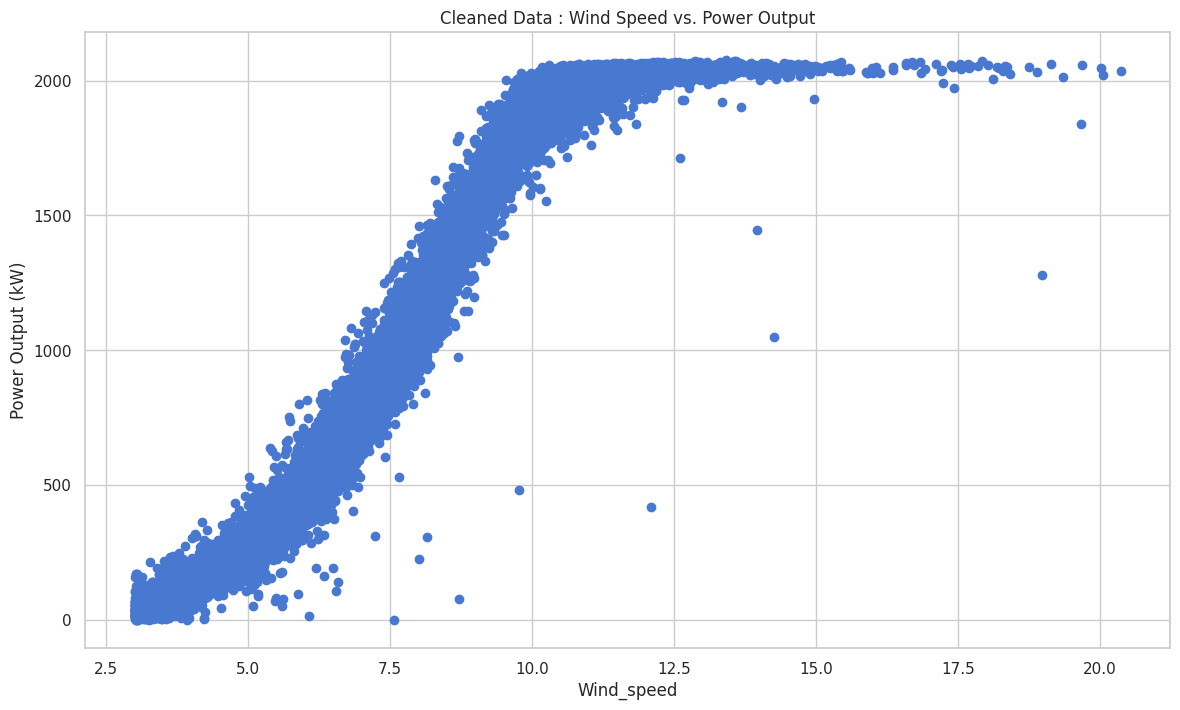

In [ ]:
# prompt: plot wind spped and power as a scatter plot

import matplotlib.pyplot as plt


# Create a scatter plot of wind speed and power
plt.scatter(data1['Wind_speed'], data1['Power'])

# Set the title and axis labels
plt.title('Cleaned Data : Wind Speed vs. Power Output')
plt.xlabel('Wind_speed')
plt.ylabel('Power Output (kW)')

# Display the plot
plt.show()

In [ ]:
# prompt: Divide wind speed interval into bins for every 1m/s.

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# Divide wind speed interval into bins for every 1m/s
data1['Wind speed bin'] = pd.cut(data1['Wind_speed'], bins=np.arange(3, 22, 1))

# Group the data by wind speed bin and calculate the mean power output
grouped_data = data1.groupby('Wind speed bin')['Power'].mean()


/tmp/ipython-input-161/2227322501.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data1.groupby('Wind speed bin')['Power'].mean()


In [ ]:
print(grouped_data)

Wind speed bin
(3, 4]        81.504968
(4, 5]       191.739224
(5, 6]       359.428075
(6, 7]       612.018760
(7, 8]       949.552143
(8, 9]      1323.086081
(9, 10]     1708.437339
(10, 11]    1937.428402
(11, 12]    2007.290223
(12, 13]    2033.062576
(13, 14]    2039.839102
(14, 15]    2027.004794
(15, 16]    2045.480674
(16, 17]    2048.481973
(17, 18]    2043.211121
(18, 19]    1971.341395
(19, 20]    1992.138492
(20, 21]    2033.985278
Name: Power, dtype: float64


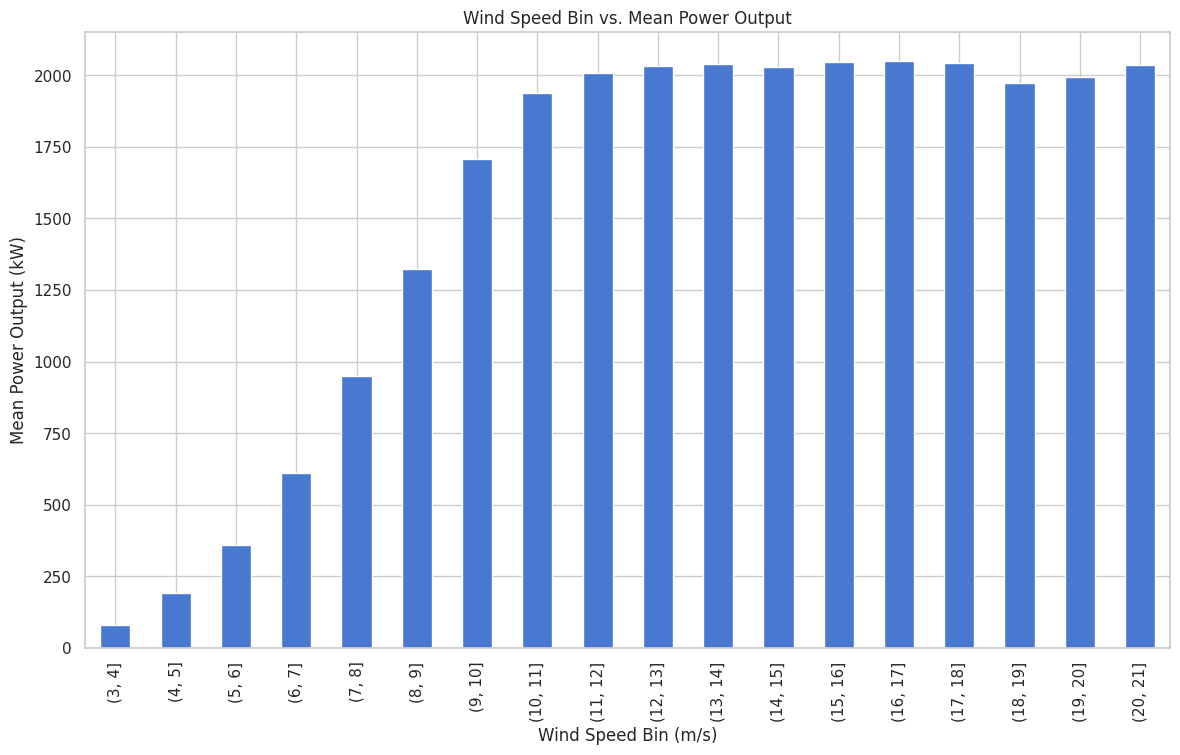

In [ ]:
# prompt: plot wind speed bin, mean power

import matplotlib.pyplot as plt
# Plot the grouped data
grouped_data.plot(kind='bar')

# Set the title and axis labels
plt.title('Wind Speed Bin vs. Mean Power Output')
plt.xlabel('Wind Speed Bin (m/s)')
plt.ylabel('Mean Power Output (kW)')

# Display the plot
plt.show()


In [ ]:
# prompt: for each bin print data whichis above mean value of power

for bin, mean in grouped_data.items():
  filtered_data = data1[(data1['Wind speed bin'] == bin) & (data1['Power'] > mean)]
  if not filtered_data.empty:
    print(f"Data points in bin {bin} that are above the mean:")
    #print(filtered_data['Power (kW)'])
    print(filtered_data['Power'].count())


Data points in bin (3, 4] that are above the mean:
1336
Data points in bin (4, 5] that are above the mean:
1584
Data points in bin (5, 6] that are above the mean:
1530
Data points in bin (6, 7] that are above the mean:
1255
Data points in bin (7, 8] that are above the mean:
893
Data points in bin (8, 9] that are above the mean:
710
Data points in bin (9, 10] that are above the mean:
572
Data points in bin (10, 11] that are above the mean:
554
Data points in bin (11, 12] that are above the mean:
486
Data points in bin (12, 13] that are above the mean:
304
Data points in bin (13, 14] that are above the mean:
135
Data points in bin (14, 15] that are above the mean:
54
Data points in bin (15, 16] that are above the mean:
12
Data points in bin (16, 17] that are above the mean:
7
Data points in bin (17, 18] that are above the mean:
10
Data points in bin (18, 19] that are above the mean:
10
Data points in bin (19, 20] that are above the mean:
3
Data points in bin (20, 21] that are above the m

In [ ]:
# prompt: remove these record from each bin which is above mean value of power and store it in csv file

import pandas as pd
from pandas import concat
# Create a new DataFrame to store the filtered data
filtered_data = pd.DataFrame()

# Iterate over each wind speed bin and mean power output
for bin, mean in grouped_data.items():
  # Filter the data for points in the current bin that are above the mean
  #filtered_data = filtered_data.append(data1[(data1['Wind speed bin'] == bin) & (data1['Power'] > mean)])
  filtered_data = concat([filtered_data, data1[(data1['Wind speed bin'] == bin) & (data1['Power'] > mean)]])


# Save the filtered data to a CSV file
filtered_data.to_csv('Cleaned_data_mean.csv', index=False)


In [ ]:
data3 = pd.read_csv('Cleaned_data_mean.csv')
data3.describe()

,Unnamed: 0,Gear_oil_inlet_pressure,Gear_oil_inlet_temp,Gear_oil_pump_pressure,Gear_oil_temp,Gearbox_speed,Generator_bearing_rear_temp,Generator_bearing_front_temp,Generator_RPM,Front_bearing_temperature,Rear_bearing_temperature,Rotor_bearing_temp,Rotor_speed,Wind_speed,Wind_direction,Power
count,9457.000000,9457.000000,9457.000000,9457.000000,9457.000000,9457.000000,9457.000000,9457.000000,9457.000000,9457.000000,9457.000000,9457.000000,9457.000000,9457.000000,9457.000000,9457.000000
mean,11571.167283,141.458541,46.090810,538.065908,53.467091,1440.022300,39.825437,37.511209,1436.558992,70.033331,66.760365,28.222276,12.110604,7.041522,186.404850,878.880791
std,6465.525964,55.677734,9.437467,168.600008,3.739036,310.298314,4.760512,5.992580,309.173710,5.036310,3.285729,3.231508,2.621165,2.756810,97.463152,701.237717
min,103.000000,63.986419,10.122500,294.549325,25.400000,614.850026,18.265000,16.605000,614.250064,40.637500,43.200000,9.812500,5.142804,3.000301,0.135386,81.519168
25%,6110.000000,89.450980,39.572500,376.943468,50.735000,1121.157469,37.081817,33.520000,1119.007782,68.112500,65.545000,26.047500,9.414780,4.833106,91.164359,246.506380
50%,11574.000000,120.413063,47.697500,484.531462,53.442500,1476.305471,39.297500,38.717500,1472.775135,71.850001,67.347501,28.280000,12.409598,6.509634,208.560371,645.420355
75%,17101.000000,198.830244,54.407501,711.947735,56.572500,1786.646925,41.997500,42.155000,1782.009768,73.407502,68.927499,30.245000,15.041023,8.814628,259.500206,1502.320563
max,23953.000000,258.061958,58.700000,836.561536,59.877501,1816.579691,73.855002,59.710000,1811.751337,77.245002,72.970000,38.395002,15.302300,20.368935,359.924828,2076.354102


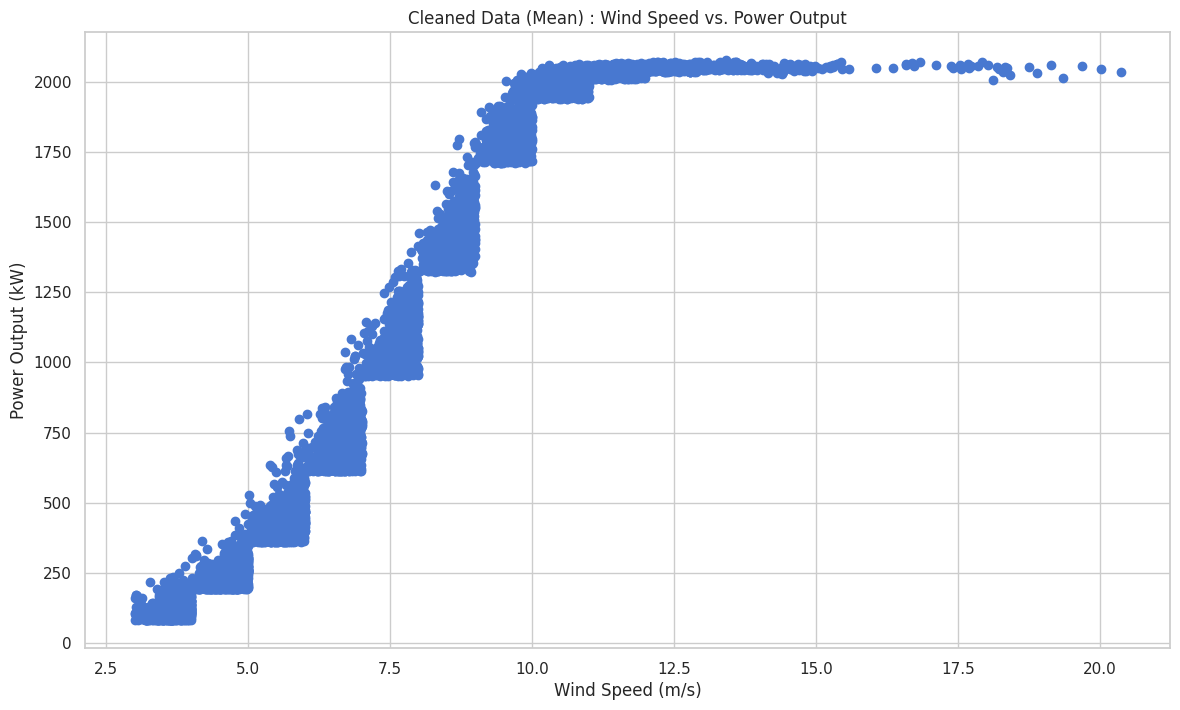

In [ ]:
# prompt: plot wind spped and power as a scatter plot
mean_data = pd.read_csv('Cleaned_data_mean.csv')
import matplotlib.pyplot as plt


# Create a scatter plot of wind speed and power
plt.scatter(mean_data['Wind_speed'], mean_data['Power'])

# Set the title and axis labels
plt.title('Cleaned Data (Mean) : Wind Speed vs. Power Output')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Power Output (kW)')

# Display the plot
plt.show()

In [ ]:
# prompt: Clean data by the standard deviation method for each bin

import pandas as pd
# Calculate the standard deviation for each wind speed bin
std_devs = data1.groupby('Wind speed bin')['Power'].std()

# Create a new DataFrame to store the cleaned data
cleaned_data = pd.DataFrame()

# Iterate over each wind speed bin and standard deviation
for bin, std_dev in std_devs.items():
  # Filter the data for points in the current bin that are within one standard deviation of the mean
  cleaned_data = concat([cleaned_data, data1[(data1['Wind speed bin'] == bin) & (data1['Power'] <= grouped_data[bin] + 2*std_dev) & (data1['Power'] >= grouped_data[bin] - 2*std_dev)]])

# Save the cleaned data to a CSV file
cleaned_data.to_csv('cleaned_data_std.csv', index=False)


/tmp/ipython-input-161/2905149085.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  std_devs = data1.groupby('Wind speed bin')['Power'].std()


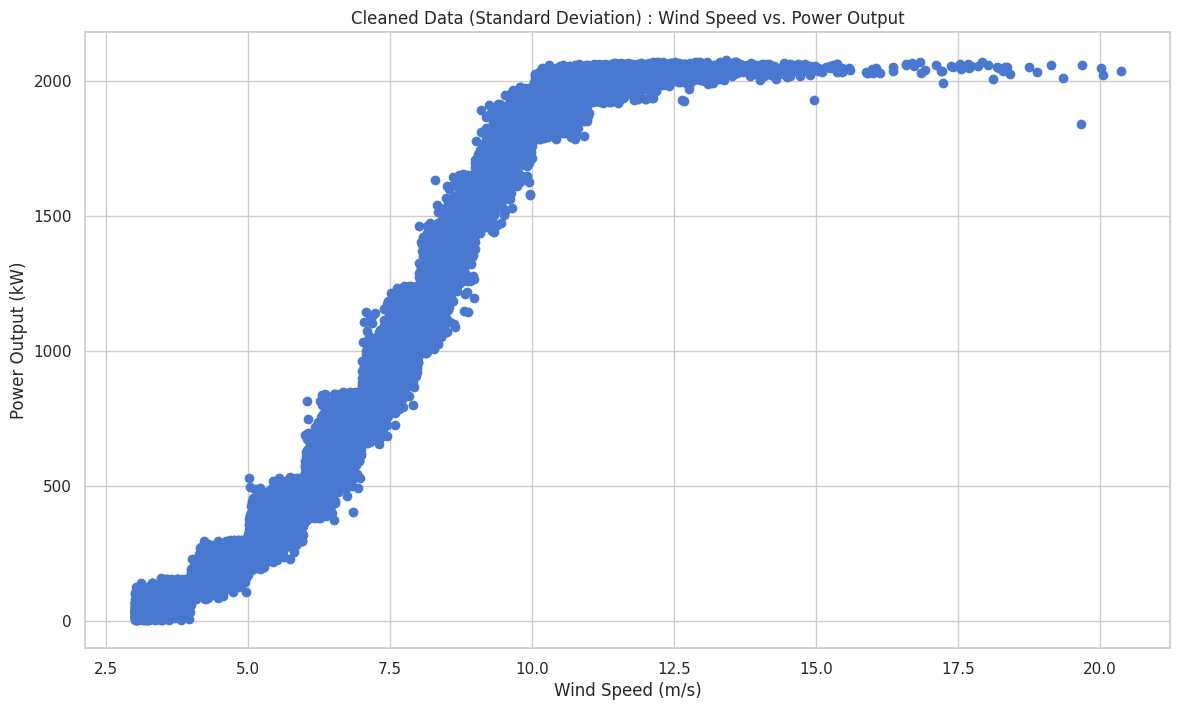

In [ ]:
# prompt: plot wind spped and power as a scatter plot
std_data = pd.read_csv('cleaned_data_std.csv')
import matplotlib.pyplot as plt


# Create a scatter plot of wind speed and power
plt.scatter(std_data['Wind_speed'], std_data['Power'])

# Set the title and axis labels
plt.title('Cleaned Data (Standard Deviation) : Wind Speed vs. Power Output')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Power Output (kW)')

# Display the plot
plt.show()

In [ ]:
std_data.describe()

,Unnamed: 0,Gear_oil_inlet_pressure,Gear_oil_inlet_temp,Gear_oil_pump_pressure,Gear_oil_temp,Gearbox_speed,Generator_bearing_rear_temp,Generator_bearing_front_temp,Generator_RPM,Front_bearing_temperature,Rear_bearing_temperature,Rotor_bearing_temp,Rotor_speed,Wind_speed,Wind_direction,Power
count,18341.000000,18341.000000,18341.000000,18341.000000,18341.000000,18341.000000,18341.000000,18341.000000,18341.000000,18341.000000,18341.000000,18341.000000,18341.000000,18341.000000,18341.000000,18341.000000
mean,11794.213075,133.646464,46.873062,517.129368,53.307187,1378.807473,40.039002,38.237065,1375.508080,68.583696,65.975603,28.174460,11.593062,6.653542,186.334089,754.841199
std,6865.510680,53.610577,8.987136,162.738738,4.333761,327.598117,4.814866,5.673763,326.410234,6.625756,4.571138,3.624951,2.766370,2.643542,95.641802,673.048771
min,101.000000,39.654383,9.475000,213.093309,14.777500,231.982444,11.630000,13.765000,232.135600,30.280000,29.450000,7.285000,1.913268,3.000301,0.057135,3.890591
25%,5818.000000,87.501336,40.481579,372.815596,50.712500,1061.393400,37.269999,34.770002,1059.596317,65.676190,64.642105,25.742500,8.914480,4.599832,96.539450,198.062057
50%,11761.000000,108.217136,48.910000,447.764865,53.564999,1350.401173,39.512500,39.375000,1346.941023,71.244445,67.097499,28.277500,11.351811,6.047706,205.948251,479.935315
75%,17929.000000,192.151065,54.599999,693.585254,56.699999,1746.495060,42.310000,42.473684,1742.013090,73.152500,68.885000,30.495000,14.702042,8.219556,258.402621,1227.271222
max,23954.000000,299.697564,58.800000,989.700613,59.905000,1816.579691,73.860001,60.245000,1811.751337,77.245002,73.164999,38.395002,15.302300,20.368935,359.990140,2076.354102


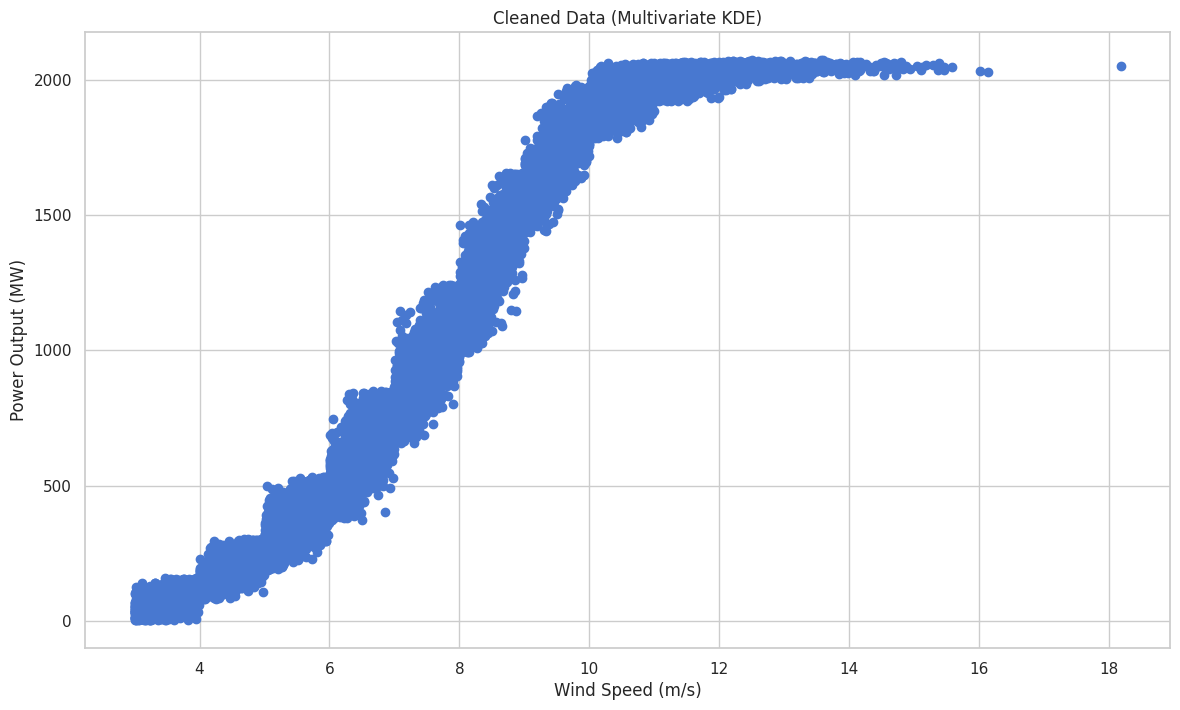

In [ ]:
# prompt: clean data using multivariate kde for std_data



# Load the data
std_data = pd.read_csv('cleaned_data_std.csv')

# Define the features to use for KDE
features = ['Wind_speed', 'Power']

# Create a Kernel Density Estimation model
kde = KernelDensity(algorithm='kd_tree', kernel='gaussian', bandwidth=0.5)

# Fit the KDE model to the data
kde.fit(std_data[features].values)

# Calculate the log-likelihood of each data point
log_likelihoods = kde.score_samples(std_data[features].values)

# Identify outliers as data points with log-likelihoods below a certain threshold
threshold = np.percentile(log_likelihoods, 1)
outliers = std_data[log_likelihoods < threshold]

# Remove outliers from the data
cleaned_data = std_data[log_likelihoods >= threshold]

# Save the cleaned data to a CSV file
cleaned_data.to_csv('cleaned_data_kde.csv', index=False)

# Create a scatter plot of the cleaned data
plt.scatter(cleaned_data['Wind_speed'], cleaned_data['Power'])
plt.title('Cleaned Data (Multivariate KDE)')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Power Output (MW)')
plt.show()


In [ ]:
print(len(cleaned_data['Wind_speed']))

18157


# **AUTOENCODER**

In [ ]:
df = pd.read_csv('cleaned_data_kde.csv',index_col=0,parse_dates=True)

/tmp/ipython-input-161/578620208.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv('cleaned_data_kde.csv',index_col=0,parse_dates=True)


In [ ]:
df.drop(['Date','Wind speed bin'], axis=1,inplace=True)

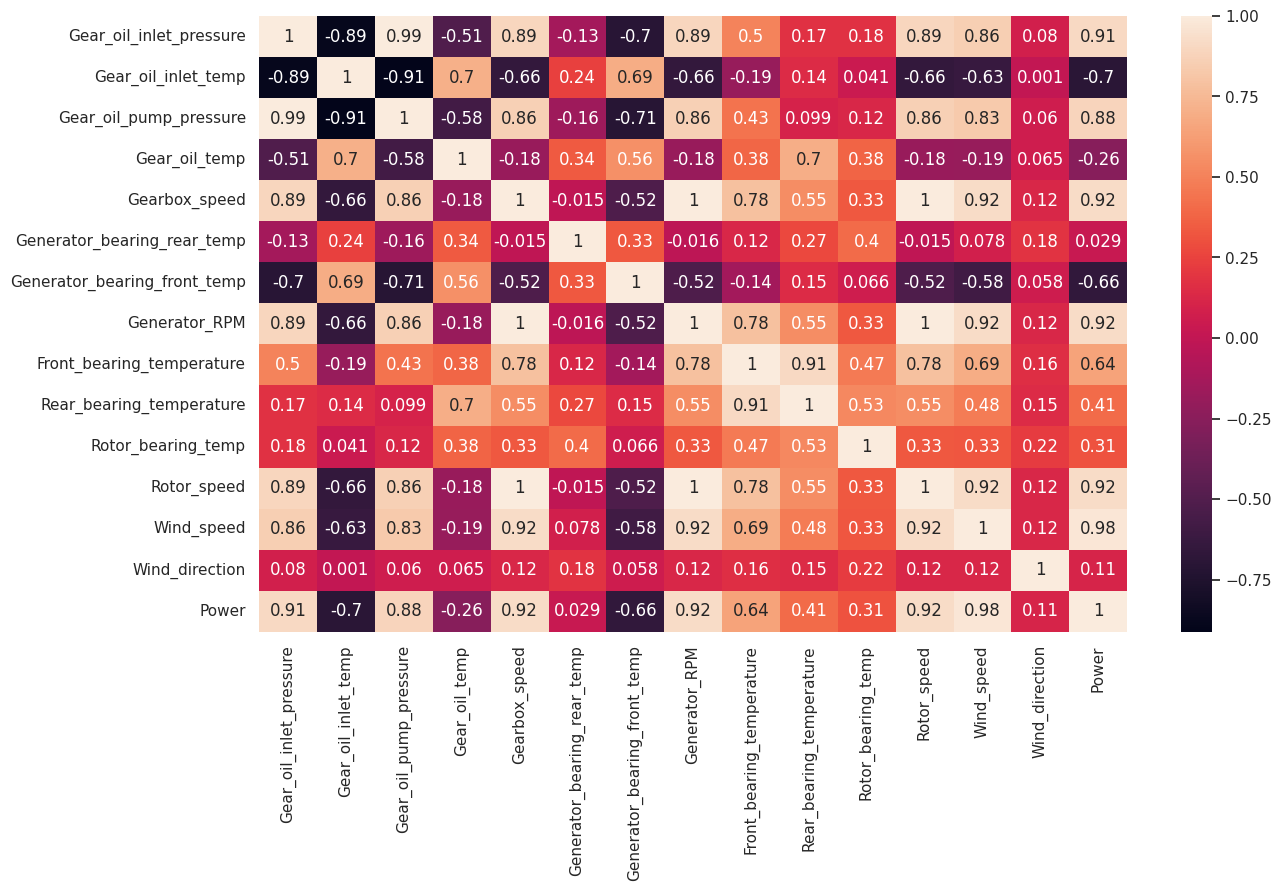

In [ ]:
column=df.columns[0:len(df.columns)-1]
corr=df[df.columns].corr()
sns.heatmap(corr, annot= True)
plt.show()

In [ ]:
def generate_datasets_for_training(data, window_size,scale=True, scaler_type=MinMaxScaler):
  _l = len(data)
  data = scaler_type().fit_transform(data)
  dataset = pd.DataFrame(data)
  #print(dataset.describe())
  Xs = []
  Ys = []
  for i in range(0, (_l - window_size)):
    # because this is an autoencoder - our Ys are the same as our Xs. No need to pull the next sequence of values
    Xs.append(data[i:i+window_size])
    Ys.append(data[i:i+window_size])
  tr_x, ts_x, tr_y, ts_y = [np.array(x) for x in train_test_split(Xs, Ys)]
  assert tr_x.shape[2] == ts_x.shape[2] == (data.shape[1] if (type(data) == np.ndarray) else len(data))
  return  (tr_x.shape[2], tr_x, tr_y, ts_x, ts_y)

In [ ]:
# batch_size = 64
# window_length = 30


# early_stop = tf.keras.callbacks.EarlyStopping(
#     monitor='val_loss', min_delta=1e-2, patience=5, verbose=0, mode='auto',
#     baseline=None, restore_best_weights=True)

# feats, X, Y, XX, YY = generate_datasets_for_training(df, window_length)

# model = keras.Sequential()
# model.add(keras.layers.LSTM(32, kernel_initializer='he_uniform', batch_input_shape=(None, window_length, feats), return_sequences=True, name='encoder_1'))
# model.add(keras.layers.LSTM(16, kernel_initializer='he_uniform', return_sequences=True, name='encoder_2'))
# model.add(keras.layers.LSTM(8, kernel_initializer='he_uniform', return_sequences=False, name='encoder_3'))
# model.add(keras.layers.RepeatVector(window_length, name='encoder_decoder_bridge'))
# model.add(keras.layers.LSTM(8, kernel_initializer='he_uniform', return_sequences=True, name='decoder_1'))
# model.add(keras.layers.LSTM(16, kernel_initializer='he_uniform', return_sequences=True, name='decoder_2'))
# model.add(keras.layers.LSTM(32, kernel_initializer='he_uniform', return_sequences=True, name='decoder_3'))
# model.add(keras.layers.TimeDistributed(keras.layers.Dense(feats)))
# model.compile(loss="mse",optimizer='adam')
# model.build()
# print(model.summary())

# history = model.fit(x=X, y=Y, validation_data = (XX,YY), epochs=100, batch_size=batch_size, shuffle=True, callbacks=[early_stop])


In [ ]:
batch_size = 64
window_length = 30


early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', min_delta=1e-2, patience=5, verbose=0, mode='auto',
    baseline=None, restore_best_weights=True)

feats, X, Y, XX, YY = generate_datasets_for_training(df, window_length)

model = keras.Sequential()
# Use input_shape for the first layer instead of batch_input_shape
model.add(keras.layers.LSTM(32, kernel_initializer='he_uniform', input_shape=(window_length, feats), return_sequences=True, name='encoder_1'))
model.add(keras.layers.LSTM(16, kernel_initializer='he_uniform', return_sequences=True, name='encoder_2'))
model.add(keras.layers.LSTM(8, kernel_initializer='he_uniform', return_sequences=False, name='encoder_3'))
model.add(keras.layers.RepeatVector(window_length, name='encoder_decoder_bridge'))
model.add(keras.layers.LSTM(8, kernel_initializer='he_uniform', return_sequences=True, name='decoder_1'))
model.add(keras.layers.LSTM(16, kernel_initializer='he_uniform', return_sequences=True, name='decoder_2'))
model.add(keras.layers.LSTM(32, kernel_initializer='he_uniform', return_sequences=True, name='decoder_3'))
model.add(keras.layers.TimeDistributed(keras.layers.Dense(feats)))
model.compile(loss="mse",optimizer='adam')
model.build() # build is still needed to set the batch size if desired, though it's not strictly necessary with input_shape
print(model.summary())

# history = model.fit(x=X, y=Y, validation_data = (XX,YY), epochs=100, batch_size=batch_size, shuffle=True, callbacks=[early_stop])
history = model.fit(x=X, y=Y, validation_data = (XX,YY), epochs=100, batch_size=batch_size, shuffle=True)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_1 (LSTM)                │ (None, 30, 32)         │         6,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_2 (LSTM)                │ (None, 30, 16)         │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_3 (LSTM)                │ (None, 8)              │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_decoder_bridge          │ (None, 30, 8)          │             0 │
│ (RepeatVector)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_1 (LSTM)                │ (None, 30, 8)          │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_2 (LSTM)                │ (None, 30, 16)         │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_3 (LSTM)                │ (None, 30, 32)         │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 30, 15)         │           495 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,991 (74.18 KB)

 Trainable params: 18,991 (74.18 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 32s 91ms/step - loss: 0.1616 - val_loss: 0.0203
Epoch 2/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 17s 78ms/step - loss: 0.0177 - val_loss: 0.0130
Epoch 3/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 16s 77ms/step - loss: 0.0122 - val_loss: 0.0105
Epoch 4/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 16s 77ms/step - loss: 0.0101 - val_loss: 0.0082
Epoch 5/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 17s 82ms/step - loss: 0.0077 - val_loss: 0.0069
Epoch 6/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 19s 77ms/step - loss: 0.0068 - val_loss: 0.0065
Epoch 7/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 16s 77ms/step - loss: 0.0064 - val_loss: 0.0063
Epoch 8/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 20s 76ms/step - loss: 0.0062 - val_loss: 0.0062
Epoch 9/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 16s 77ms/step - loss: 0.0061 - val_loss: 0.0061
Epoch 10/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 17s 80ms/step - loss: 0.0060 - val_loss: 0.0059
Epoch 11/100
213/213 ━━━━━━━━━━━━━━━━━━━━ 17s 77ms/step - loss: 0.0059 - val_loss: 0.0057
Epoch 12/100
2

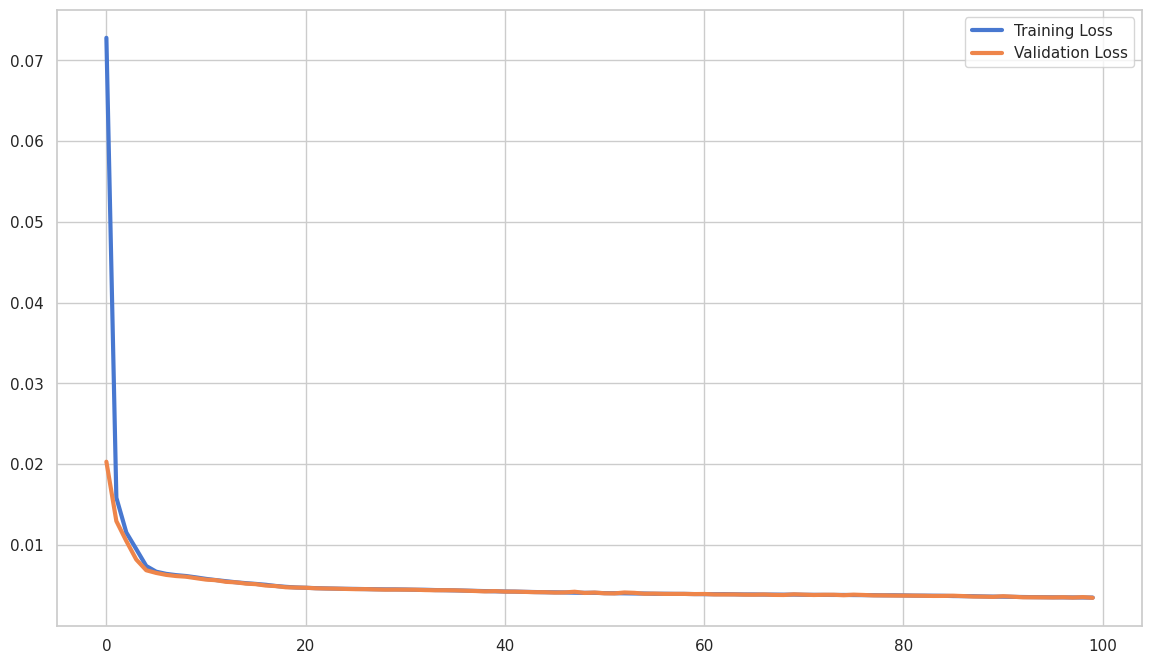

In [ ]:
plt.plot(history.history['loss'],
         label='Training Loss',
         linewidth=3)

plt.plot(history.history['val_loss'],
         label='Validation Loss',
         linewidth=3)

plt.legend()

# Save in high resolution
plt.savefig('training_validation_loss.png', dpi=600, bbox_inches='tight')


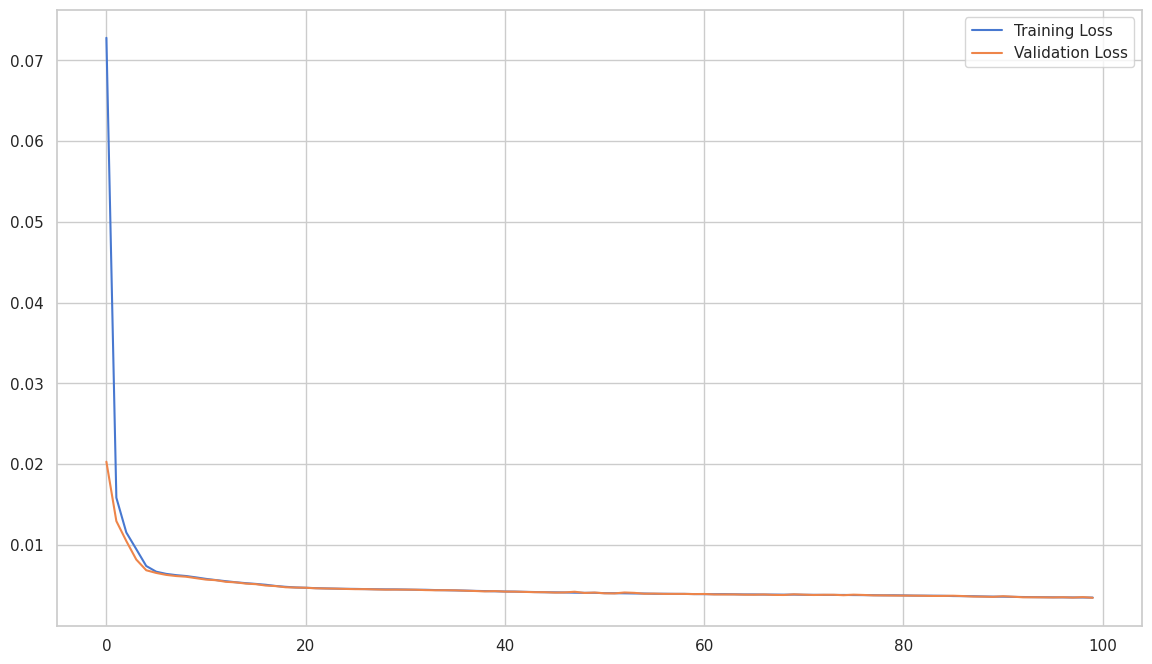

In [ ]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend();

In [ ]:
X_train_pred = model.predict(X)
train_mae_loss = pd.DataFrame(np.mean(np.abs(X_train_pred - X), axis=1))
train_mae_loss

425/425 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,0.011338,0.012876,0.012303,0.013714,0.020333,0.018938,0.042231,0.020983,0.015261,0.014919,0.018269,0.021108,0.014456,0.120672,0.014134
1,0.049812,0.062455,0.045388,0.027416,0.012946,0.032115,0.102824,0.013051,0.023183,0.025907,0.017843,0.012938,0.016634,0.034196,0.061574
2,0.066220,0.089758,0.069574,0.043149,0.035392,0.019561,0.049647,0.036558,0.026672,0.033783,0.049266,0.036775,0.017006,0.095737,0.037359
3,0.022962,0.035736,0.024420,0.013424,0.003003,0.020810,0.024227,0.002594,0.018781,0.015185,0.020049,0.003036,0.014763,0.133083,0.016800
4,0.033271,0.051166,0.012367,0.023450,0.008264,0.078178,0.041307,0.009141,0.019357,0.020316,0.100632,0.005058,0.015881,0.065704,0.042471
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13590,0.038480,0.063785,0.044985,0.027980,0.004106,0.081819,0.066291,0.006160,0.016819,0.024331,0.042977,0.004217,0.025204,0.132031,0.009645
13591,0.012054,0.026551,0.020448,0.031188,0.013202,0.029453,0.040935,0.015667,0.044380,0.038053,0.036188,0.018923,0.017900,0.211095,0.012345
13592,0.090858,0.086288,0.088139,0.029614,0.023049,0.020669,0.077254,0.021639,0.017984,0.030941,0.047093,0.022412,0.016269,0.027078,0.040775
13593,0.018000,0.055630,0.019633,0.011323,0.004373,0.031144,0.057163,0.004914,0.016660,0.009128,0.018625,0.004125,0.022582,0.053268,0.012035


# **Set Threshold**

In [ ]:
loss_threshold =np.percentile (train_mae_loss, 98)
print(f'The prediction loss threshold for 2% of outliers is {loss_threshold:.2f}')

The prediction loss threshold for 2% of outliers is 0.11


/tmp/ipython-input-161/1731640021.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train_mae_loss, bins=50, kde=True);


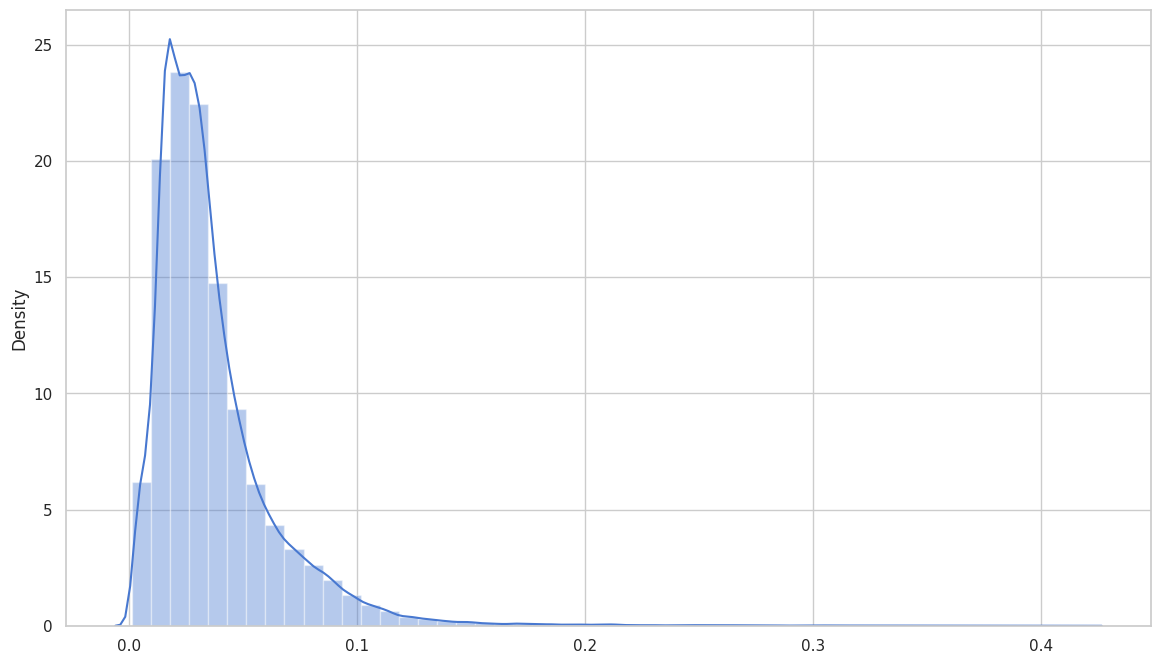

In [ ]:
sns.distplot(train_mae_loss, bins=50, kde=True);

# **Testing on faulty data without label**

In [ ]:
df1 = pd.read_csv('CM_data.csv',index_col=0,parse_dates=True)
#df1.isnull().sum(axis = 0)
df1.fillna(df1.mean(), inplace=True)

In [ ]:
def generate_datasets_for_training(data, window_size,scale=True, scaler_type=MinMaxScaler):
  _l = len(data)
  data = scaler_type().fit_transform(data)
  dataset = pd.DataFrame(data)
  #print(dataset.describe())
  Xs = []
  Ys = []
  for i in range(0, (_l - window_size)):
    # because this is an autoencoder - our Ys are the same as our Xs. No need to pull the next sequence of values
    Xs.append(data[i:i+window_size])
    Ys.append(data[i:i+window_size])
  tr_x, tr_y = [np.array(x) for x in (Xs, Ys)]
  assert tr_x.shape[2] == (data.shape[1] if (type(data) == np.ndarray) else len(data))
  return  (tr_x.shape[2], tr_x, tr_y)

In [ ]:
feats, XX, YY = generate_datasets_for_training(df1, window_length)

In [ ]:
#model.evaluate(XX, YY)

In [ ]:
X_test_pred = model.predict(XX)
#test_mae_loss = np.mean(np.abs(X_test_pred - XX), axis=1)
test_mae_loss =pd.DataFrame(np.mean(np.abs(X_test_pred - XX), axis=1))


814/814 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step


In [ ]:
print(pd.DataFrame(test_mae_loss))

             0         1         2         3         4         5         6   \
0      0.255741  0.417390  0.275457  0.355448  0.303842  0.460654  0.401002   
1      0.259304  0.415413  0.280031  0.353584  0.303462  0.458698  0.399214   
2      0.259509  0.413932  0.277625  0.353126  0.298615  0.463079  0.401937   
3      0.260650  0.411511  0.278633  0.352067  0.298103  0.460647  0.401089   
4      0.264370  0.408559  0.283766  0.350510  0.297803  0.458410  0.399201   
...         ...       ...       ...       ...       ...       ...       ...   
26029  0.116335  0.220534  0.132949  0.153708  0.177252  0.037784  0.069160   
26030  0.123072  0.211310  0.142963  0.149581  0.170189  0.043085  0.067116   
26031  0.132449  0.199511  0.155883  0.147093  0.162625  0.048101  0.063813   
26032  0.140260  0.191635  0.165959  0.147054  0.153276  0.050572  0.061949   
26033  0.142030  0.188264  0.168830  0.154204  0.158280  0.055550  0.057741   

             7         8         9         10      

# **Threshold**

In [ ]:
#Check the prediction loss threshold for 28 of outliers
loss_threshold_ud =np.percentile (test_mae_loss, 98)
print(f'The prediction loss threshold for 2% of outliers is {loss_threshold_ud:.2f}')

The prediction loss threshold for 2% of outliers is 0.30


In [ ]:
loss_threshold_ud=0.43

In [ ]:
# prompt: drop first 30 rows from df1
df1 = pd.read_csv('CM_data.csv',index_col=0,parse_dates=True)
df1.isnull().sum(axis = 0)
df1.fillna(df1.mean(), inplace=True)

In [ ]:
df1 = df1.iloc[window_length:]
av = test_mae_loss.mean(axis=1)
df1['anomaly_score'] = av.values
df1['anomaly'] = 0
df1.loc[df1['anomaly_score'] > loss_threshold_ud, 'anomaly'] = 1

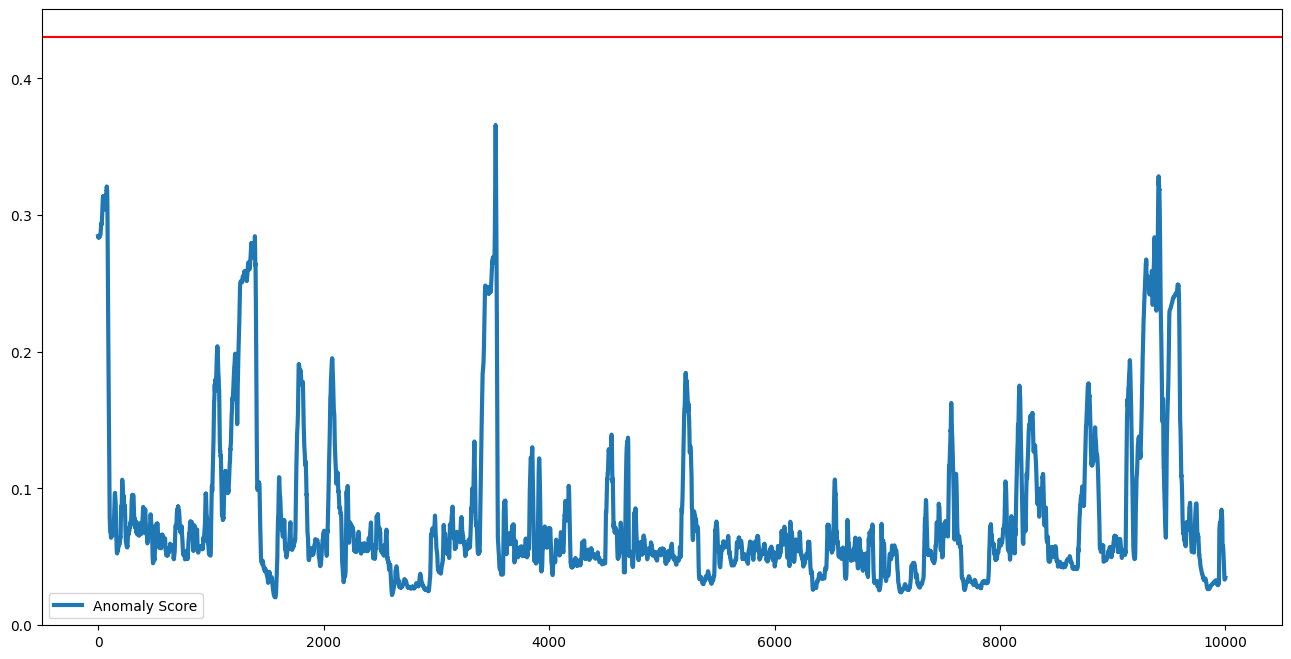

In [ ]:
plt.style.use('default')
plt.figure(figsize=(16, 8))
plt.rcParams['axes.facecolor'] = 'white'
plt.plot(av[0:10000], label='Anomaly Score',linewidth=3)
plt.axhline(y=loss_threshold_ud, color='red')
# plt.xlabel('X-axis Label', fontsize=14, fontweight='bold')
# plt.ylabel('Y-axis Label', fontsize=14, fontweight='bold')

plt.legend()
plt.savefig('anomaly_score.png',
            dpi=600,
            bbox_inches='tight',
            facecolor='white')
plt.show()

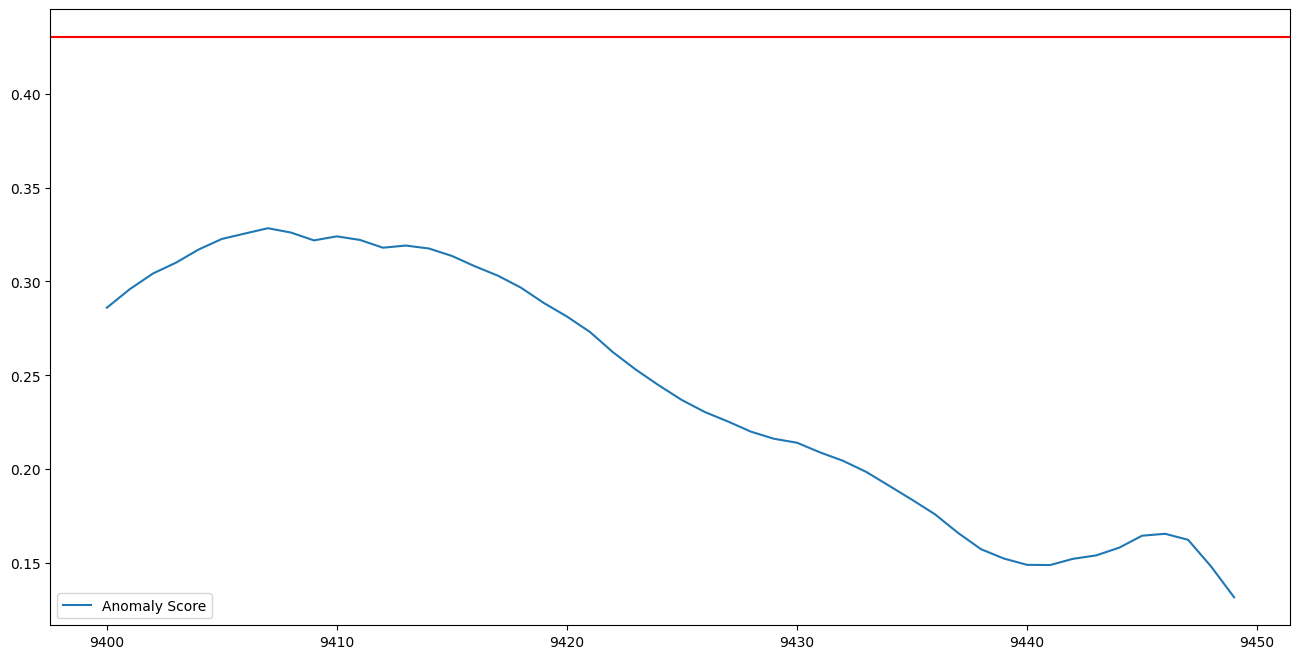

In [ ]:
plt.figure(figsize=(16, 8))
plt.plot(av[9400:9450], label='Anomaly Score')
plt.axhline(y=loss_threshold_ud, color='red')
plt.legend()
plt.show()

In [ ]:
test_mae_loss.to_csv("sh.csv",index=False)

In [ ]:
test_mae_loss[1298:1394]

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
1298,0.233064,0.363636,0.284819,0.298402,0.327615,0.341733,0.257639,0.313288,0.056608,0.194289,0.271804,0.352720,0.282503,0.205590,0.084430
1299,0.236388,0.360682,0.290819,0.296638,0.326805,0.341373,0.256600,0.312735,0.059507,0.193776,0.270924,0.352949,0.285041,0.205871,0.084556
1300,0.231274,0.363391,0.284115,0.301043,0.325000,0.348468,0.263588,0.311277,0.051245,0.194157,0.279027,0.350761,0.288209,0.205432,0.085668
1301,0.231615,0.359562,0.284232,0.297940,0.323490,0.347218,0.262678,0.310283,0.049707,0.191768,0.279109,0.350345,0.290752,0.205733,0.086019
1302,0.235829,0.355194,0.293464,0.294301,0.322228,0.345744,0.260247,0.309303,0.053127,0.189755,0.276961,0.350547,0.291182,0.206805,0.086354
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1389,0.247701,0.219299,0.316751,0.243712,0.388691,0.228556,0.201864,0.382379,0.323486,0.327082,0.221133,0.388869,0.262995,0.212902,0.120617
1390,0.242507,0.231871,0.312803,0.264719,0.407884,0.245662,0.211263,0.396723,0.367163,0.357115,0.215094,0.400326,0.237075,0.187634,0.128820
1391,0.238051,0.249198,0.298437,0.272880,0.422586,0.255156,0.215267,0.406777,0.397165,0.373769,0.206552,0.411384,0.208536,0.162620,0.148505
1392,0.233184,0.261723,0.283664,0.258457,0.423630,0.247192,0.207228,0.408350,0.407339,0.373474,0.186634,0.415930,0.175756,0.136137,0.159886


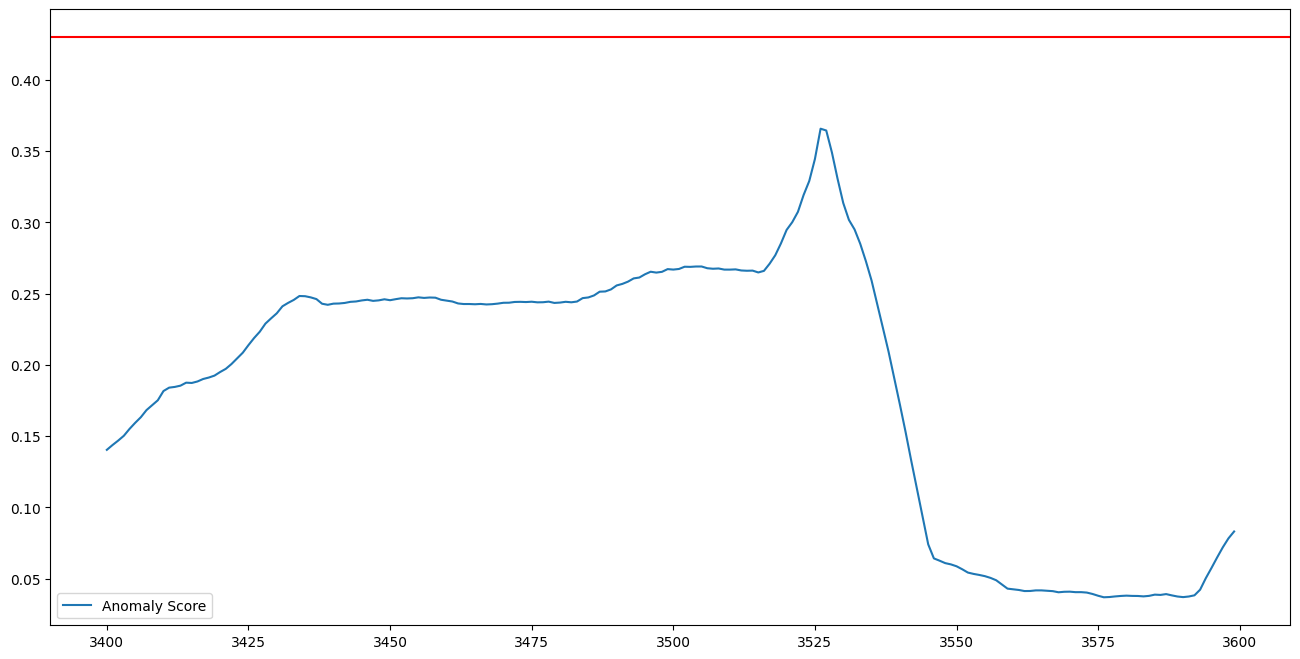

In [ ]:
plt.figure(figsize=(16, 8))
plt.plot(av[3400:3600], label='Anomaly Score')
plt.axhline(y=loss_threshold_ud, color='red')
plt.legend()
plt.show()

# **Testing on Faulty data with label**

In [ ]:
df2 = pd.read_csv('Anomaly_data.csv',index_col=0,parse_dates=True)
#df1.isnull().sum(axis = 0)
df2.fillna(df2.mean(), inplace=True)
df2['anomaly'] = df2['anomaly'].astype('int64')

In [ ]:
def generate_datasets_for_testing(data, window_size,scale=True, scaler_type=MinMaxScaler):
  _l = len(data)
  data = scaler_type().fit_transform(data)
  dataset = pd.DataFrame(data)
  #print(dataset.describe())
  Xs = []
  Ys = []
  for i in range(0, (_l - window_size)):
    # because this is an autoencoder - our Ys are the same as our Xs. No need to pull the next sequence of values
    Xs.append(data[i:i+window_size])
    Ys.append(data[i:i+window_size])
  tr_x, tr_y = [np.array(x) for x in (Xs, Ys)]
  assert tr_x.shape[2] == (data.shape[1] if (type(data) == np.ndarray) else len(data))
  return  (tr_x.shape[2], tr_x, tr_y)

In [ ]:
feats, XX, YY = generate_datasets_for_testing(df2.iloc[:,0:15], window_length)

In [ ]:
#model.evaluate(XX, YY)

In [ ]:
X_test_pred = model.predict(XX)
#test_mae_loss = np.mean(np.abs(X_test_pred - XX), axis=1)
test_mae_loss =pd.DataFrame(np.mean(np.abs(X_test_pred - XX), axis=1))

814/814 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step


In [ ]:
#Check the prediction loss threshold
#loss_threshold =np.percentile (test_mae_loss, 98)
print(f'The prediction loss threshold for 2% of outliers is {loss_threshold_ud:.2f}')

The prediction loss threshold for 2% of outliers is 0.43


In [ ]:
#loss_threshold_ud =0.10

In [ ]:
# prompt: drop first 30 rows from df1
df2 = df2.iloc[window_length:]
av = test_mae_loss.mean(axis=1)

In [ ]:

df2['anomaly_score'] = av.values
df2['predicted_anomaly'] = 0
df2.loc[df2['anomaly_score'] > loss_threshold_ud, 'predicted_anomaly'] = 1
#df2['predicted_anomaly'] = (df2['predicted_anomaly'] > loss_threshold_ud).astype(int)

In [ ]:
from sklearn.metrics import classification_report
#df2['predicted_anomaly'] = df2['predicted_anomaly'].round()

conf_matrix= classification_report(df2['anomaly'], df2['predicted_anomaly'])

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
print(conf_matrix)

              precision    recall  f1-score   support

           0       0.85      1.00      0.92     22181
           1       0.00      0.00      0.00      3853

    accuracy                           0.85     26034
   macro avg       0.43      0.50      0.46     26034
weighted avg       0.73      0.85      0.78     26034



In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Generate confusion matrix for the predictions
conf_matrix = confusion_matrix(df2['anomaly'], df2['predicted_anomaly'])
conf_matrix

array([[22181,     0],
       [ 3853,     0]])

In [ ]:
df2['anomaly'].value_counts()

,count
anomaly,
0,22181
1,3853


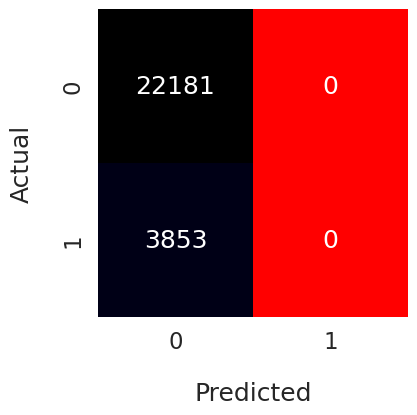

In [ ]:
plt.figure(figsize=(4,4))
sns.set(font_scale = 1.5)

ax = sns.heatmap(
    conf_matrix, # confusion matrix 2D array
    annot=True, # show numbers in the cells
    fmt='d', # show numbers as integers
    cbar=False, # don't show the color bar
    cmap='flag', # customize color map
    #vmax=175 # to get better color contrast
)

ax.set_xlabel("Predicted", labelpad=20)
ax.set_ylabel("Actual", labelpad=20)
plt.show()

In [ ]:
precision = precision_score(df2['anomaly'], df2['predicted_anomaly'])
recall = recall_score(df2['anomaly'], df2['predicted_anomaly'])
f1score = f1_score(df2['anomaly'], df2['predicted_anomaly'])

print(f"Precision = {precision}")
print(f"Recall = {recall}")
print(f"F1 Score = {f1score}")

Precision = 0.0
Recall = 0.0
F1 Score = 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Precision = 0.31197183098591547
Recall = 0.8054545454545454
F1 Score = 0.449746192893401
90%

Precision = 0.021325059890821976
Recall = 0.9872727272727273
F1 Score = 0.04174835659093531 85%

/tmp/ipython-input-161/3804869202.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(test_mae_loss, bins=50, kde=True);


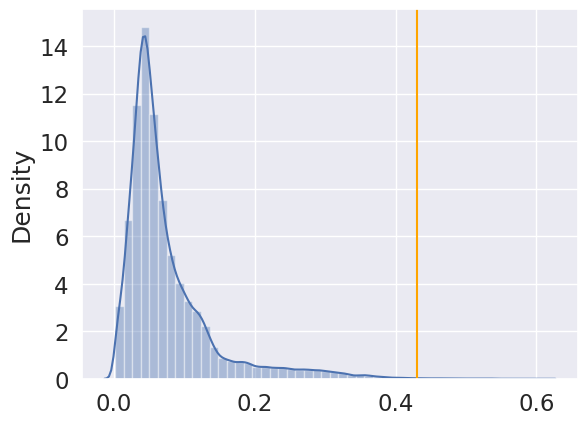

In [ ]:
sns.distplot(test_mae_loss, bins=50, kde=True);
plt.axvline(x=loss_threshold_ud, color='orange')

In [ ]:
test_mae_loss.columns = ['Gear_oil_inlet_pressure', 'Gear_oil_inlet_temp',
       'Gear_oil_pump_pressure', 'Gear_oil_temp', 'Gearbox_speed',
       'Generator_bearing_rear_temp', 'Generator_bearing_front_temp',
       'Generator_RPM', 'Front_bearing_temperature',
       'Rear_bearing_temperature', 'Rotor_bearing_temp', 'Rotor_speed',
       'Wind_speed', 'Wind_direction', 'Power']
#print(test_mae_loss)

In [ ]:
gearbox_anomaly_score = test_mae_loss.iloc[:,0:5].mean(axis=1)
generator_anomaly_score = test_mae_loss.iloc[:,5:12].mean(axis=1)

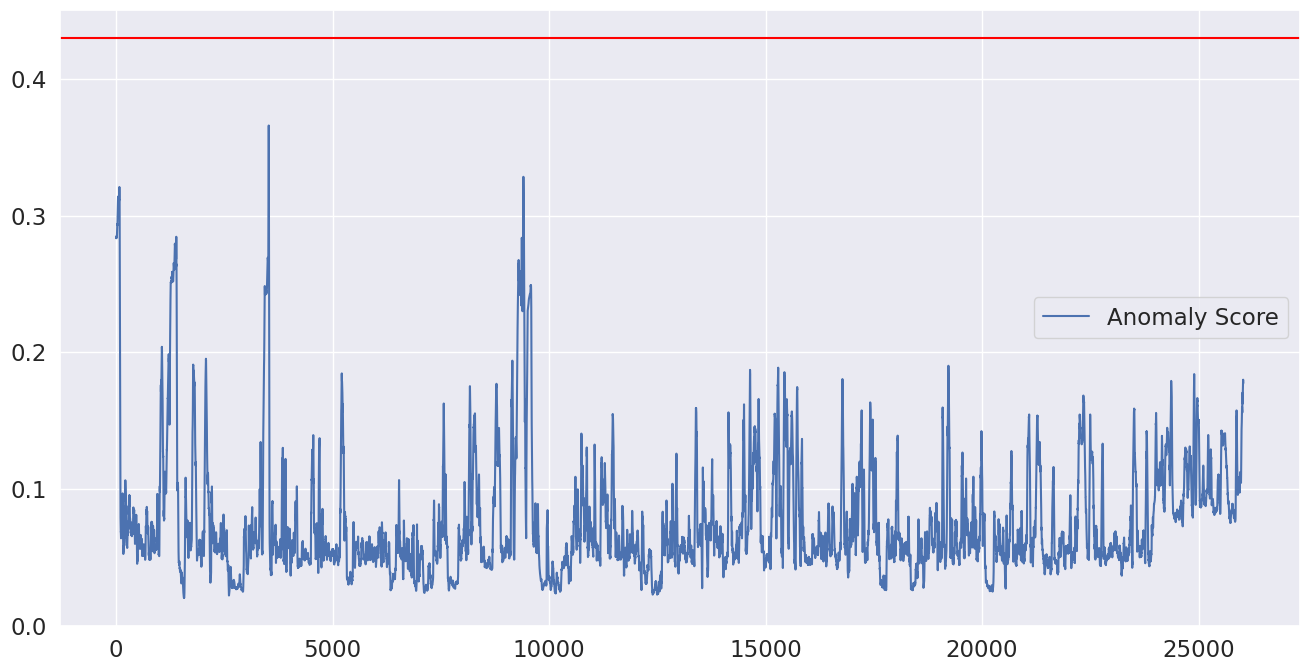

In [ ]:
plt.figure(figsize=(16, 8))
plt.plot(av, label='Anomaly Score')
plt.axhline(y=loss_threshold_ud, color='red')
plt.legend()
plt.show()

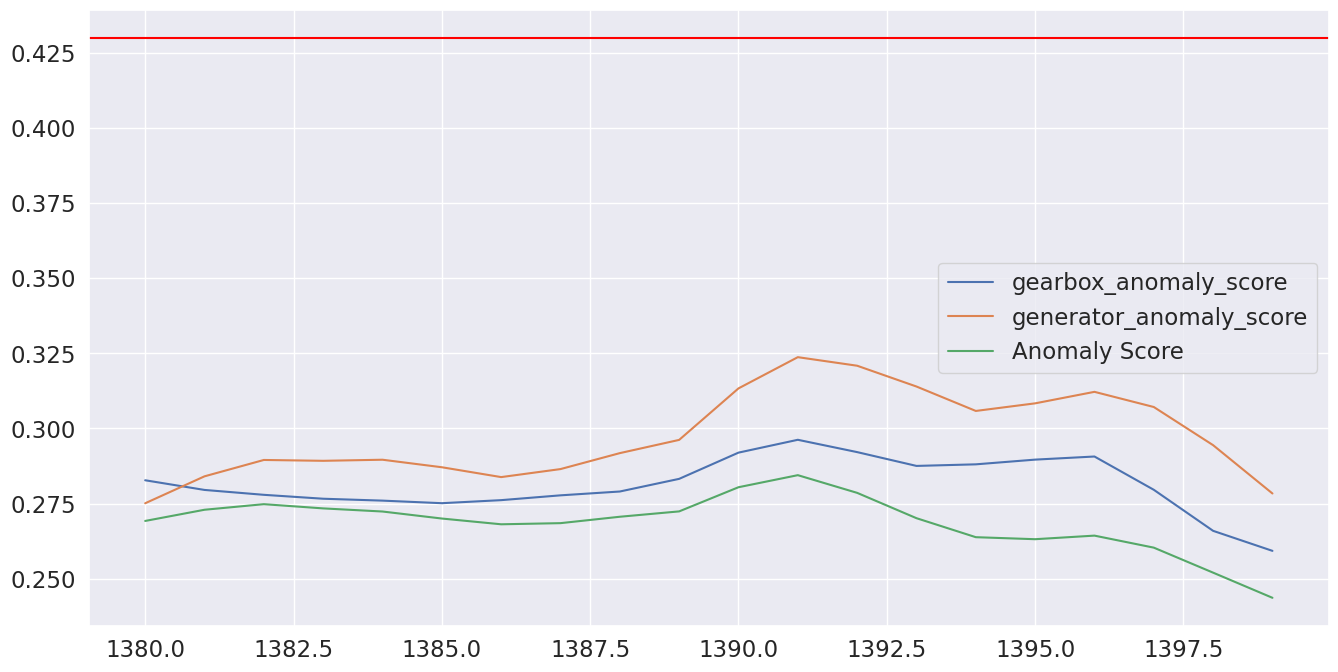

In [ ]:
plt.figure(figsize=(16, 8))
plt.plot(gearbox_anomaly_score[1380:1400], label='gearbox_anomaly_score')
plt.plot(generator_anomaly_score[1380:1400], label='generator_anomaly_score')
plt.plot(av[1380:1400], label='Anomaly Score')
plt.axhline(y=loss_threshold_ud, color='red')
plt.legend()
plt.show()

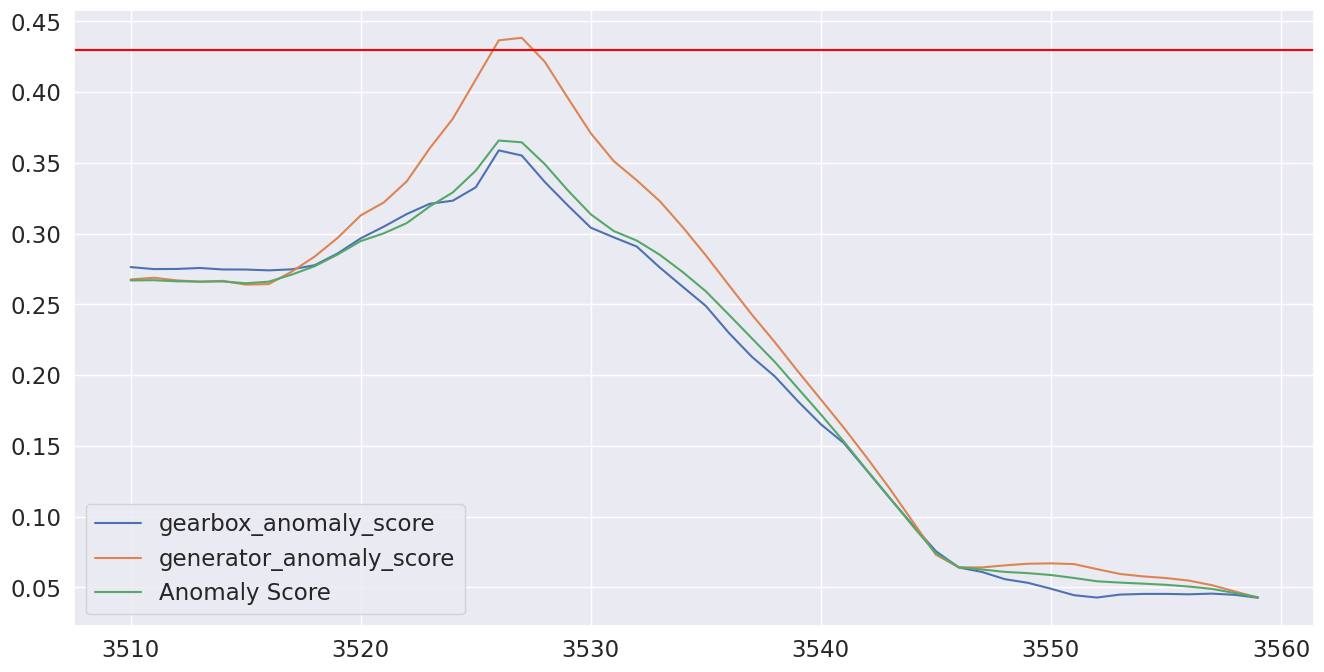

In [ ]:
plt.figure(figsize=(16, 8))
plt.plot(gearbox_anomaly_score[3510:3560], label='gearbox_anomaly_score')
plt.plot(generator_anomaly_score[3510:3560], label='generator_anomaly_score')
plt.plot(av[3510:3560], label='Anomaly Score')
plt.axhline(y=loss_threshold_ud, color='red')
plt.legend()
plt.show()

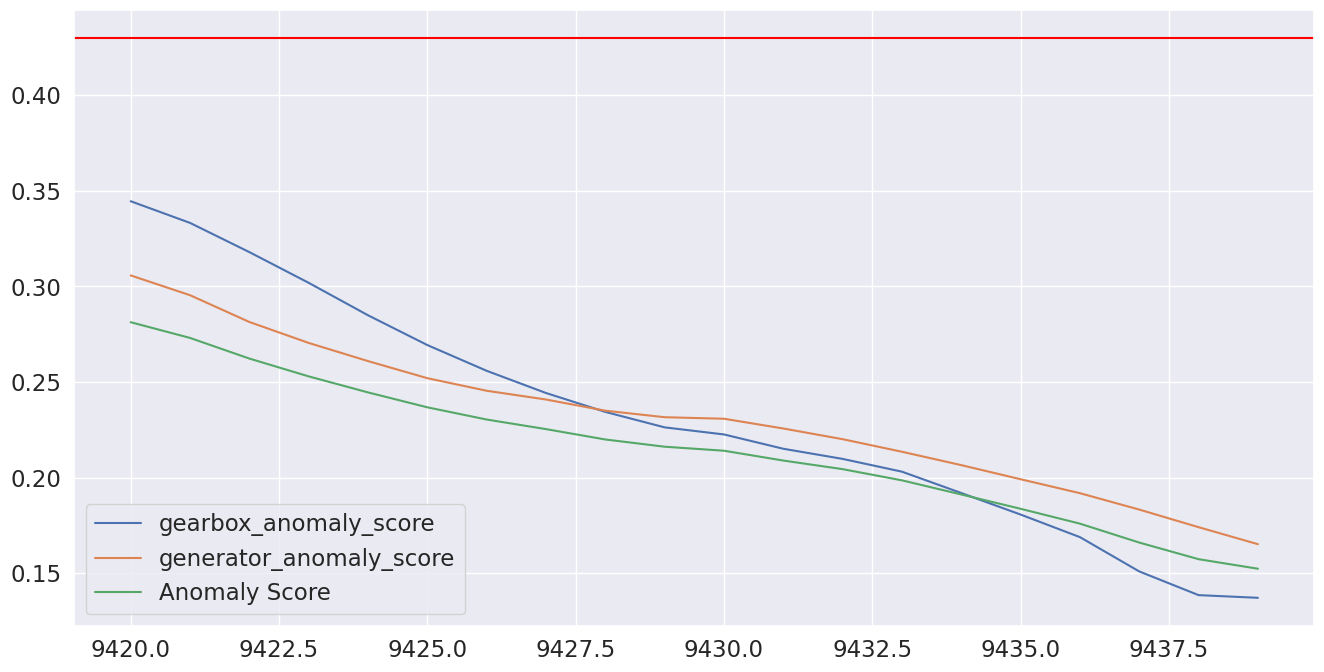

In [ ]:
plt.figure(figsize=(16, 8))
plt.plot(gearbox_anomaly_score[9420:9440], label='gearbox_anomaly_score')
plt.plot(generator_anomaly_score[9420:9440], label='generator_anomaly_score')
plt.plot(av[9420:9440], label='Anomaly Score')
plt.axhline(y=loss_threshold_ud, color='red')
plt.legend()
plt.show()

In [ ]:
test_mae_loss.mean()

,0
Gear_oil_inlet_pressure,0.086173
Gear_oil_inlet_temp,0.091742
Gear_oil_pump_pressure,0.125343
Gear_oil_temp,0.058112
Gearbox_speed,0.092905
Generator_bearing_rear_temp,0.048745
Generator_bearing_front_temp,0.059011
Generator_RPM,0.095094
Front_bearing_temperature,0.058660
Rear_bearing_temperature,0.060789


## **End**

In [ ]:
# record end time
import time
end = time.time()
emd_time = (end-start)
# print the difference between start
# and end time in milli. secs
print("The time of execution of EMD-LSTM is :",emd_time * 10**3, "ms")

The time of execution of EMD-LSTM is : 1887553.593635559 ms
